<a href="https://colab.research.google.com/github/luisina14BIO/Proyecto-Farmacovigilancia-/blob/main/Proyecto_Farmacovigilancia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib scipy


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving fda_staging.csv to fda_staging.csv


In [ ]:
import pandas as pd

df = pd.read_csv("fda_staging.csv")
df.head()


,report_id,receive_date,searched_drug,reaction,serious,death,hospitalization,patient_sex,patient_age,patient_weight,country
0,10003301,20140228,IBUPROFEN,Dyspepsia,1,NaN,NaN,2.0,NaN,NaN,NaN
1,10003301,20140228,IBUPROFEN,Renal impairment,1,NaN,NaN,2.0,NaN,NaN,NaN
2,10003319,20140312,IBUPROFEN,Cholecystectomy,1,NaN,1.0,2.0,46.0,NaN,US
3,10003319,20140312,IBUPROFEN,Nephrolithiasis,1,NaN,1.0,2.0,46.0,NaN,US
4,10003319,20140312,IBUPROFEN,Biliary tract disorder,1,NaN,1.0,2.0,46.0,NaN,US


In [ ]:
import pandas as pd

# Mostrar resumen rápido para ver columnas, tipos y valores nulos
print("Información general del dataset:")
print(df.info())

print("\nCantidad de valores nulos por columna:")
print(df.isnull().sum())


#Homogeneizar texto
df["searched_drug"] = (
    df["searched_drug"]
    .str.upper()
)
df["reaction"] = (
    df["reaction"]
    .str.upper()
)

#Convertir sexo FDA a Male y Female
sex_map = {
    1: "MALE",
    2: "FEMALE"
}

df["patient_sex"] = (
    df["patient_sex"]
    .map(sex_map)
)

#Convertir fechas
df["receive_date"] = pd.to_datetime(
    df["receive_date"],
    format="%Y%m%d",
    errors="coerce"
)

#Convertir edades a valores numéricos
df["patient_age"] = pd.to_numeric(
    df["patient_age"],
    errors="coerce"
)

#Limpieza de outliers de edades:
df = df[
    (df["patient_age"].isna()) |
    (
        (df["patient_age"] >= 0) &
        (df["patient_age"] <= 120)
    )
]

#Limpieza de columnas de severidad:
severity_map = {
    1: "YES"
}

df["serious"] = (
    df["serious"]
    .map(severity_map)
    .fillna("NO")
)

df["death"] = (
    df["death"]
    .map(severity_map)
    .fillna("NO")
)

df["hospitalization"] = (
    df["hospitalization"]
    .map(severity_map)
    .fillna("NO")
)

#Convertir peso a numérico
df["patient_weight"] = pd.to_numeric(
    df["patient_weight"],
    errors="coerce"
)

#Limpieza de outliers de peso
df = df[
    (df["patient_weight"].isna()) |
    (
        (df["patient_weight"] >= 2) &
        (df["patient_weight"] <= 250)
    )
]



Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17223 entries, 0 to 17222
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   report_id        17223 non-null  int64  
 1   receive_date     17223 non-null  int64  
 2   searched_drug    17223 non-null  object 
 3   reaction         17223 non-null  object 
 4   serious          17223 non-null  int64  
 5   death            2242 non-null   float64
 6   hospitalization  7721 non-null   float64
 7   patient_sex      16985 non-null  float64
 8   patient_age      14397 non-null  float64
 9   patient_weight   8669 non-null   float64
 10  country          14190 non-null  object 
dtypes: float64(5), int64(3), object(3)
memory usage: 1.4+ MB
None

Cantidad de valores nulos por columna:
report_id              0
receive_date           0
searched_drug          0
reaction               0
serious                0
death              14981
hos

In [ ]:
#Revisar nuevamente nulos
df.isnull().sum()

,0
report_id,0
receive_date,0
searched_drug,0
reaction,0
serious,0
death,0
hospitalization,0
patient_sex,505
patient_age,2824
patient_weight,8528


In [ ]:
#Revisar DataFrame luego de efectuada la limpieza
df.head()

,report_id,receive_date,searched_drug,reaction,serious,death,hospitalization,patient_sex,patient_age,patient_weight,country
0,10003301,2014-02-28,IBUPROFEN,DYSPEPSIA,YES,NO,NO,FEMALE,NaN,NaN,NaN
1,10003301,2014-02-28,IBUPROFEN,RENAL IMPAIRMENT,YES,NO,NO,FEMALE,NaN,NaN,NaN
2,10003319,2014-03-12,IBUPROFEN,CHOLECYSTECTOMY,YES,NO,YES,FEMALE,46.0,NaN,US
3,10003319,2014-03-12,IBUPROFEN,NEPHROLITHIASIS,YES,NO,YES,FEMALE,46.0,NaN,US
4,10003319,2014-03-12,IBUPROFEN,BILIARY TRACT DISORDER,YES,NO,YES,FEMALE,46.0,NaN,US


In [ ]:
import numpy as np

# Identificar columnas numéricas y categóricas
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

print("Medidas para variables numéricas:")
for col in numeric_cols:
    media = df[col].mean()
    mediana = df[col].median()
    moda = df[col].mode()
    moda_val = moda.iloc[0] if not moda.empty else np.nan
    print(f"{col} - media: {media:.2f}, mediana: {mediana:.2f}, moda: {moda_val}")

print("\nModa para variables categóricas:")
for col in categorical_cols:
    moda = df[col].mode()
    moda_val = moda.iloc[0] if not moda.empty else 'N/A'
    print(f"{col} - moda: {moda_val}")

Medidas para variables numéricas:
report_id - media: 10077751.31, mediana: 10061719.00, moda: 10018929
patient_age - media: 51.11, mediana: 53.00, moda: 49.0
patient_weight - media: 80.44, mediana: 77.10, moda: 59.0

Moda para variables categóricas:
searched_drug - moda: NAPROXEN
reaction - moda: TOXICITY TO VARIOUS AGENTS
serious - moda: YES
death - moda: NO
hospitalization - moda: NO
patient_sex - moda: FEMALE
country - moda: US


Media: Promedio de un conjunto de valores; útil para observar el comportamiento general de variables cuantitativas.

Mediana: Valor central que divide los datos en dos partes iguales, menos sensible a valores extremos.

Moda: Valor que más se repite, importante para entender la categoría o valor más frecuente.

In [ ]:
#Análisis por segmentos
segment_col = 'searched_drug'

if segment_col not in df.columns:
    print(f"searched_drug'{segment_col}' no existe en el dataset. Elige otra columna categórica de: {list(categorical_cols)}")
else:
    grouped = df.groupby(segment_col)
    for col in numeric_cols:
        print(f"\nMedidas para {col} segmentadas por {segment_col}:")
        measures = grouped[col].agg(['mean', 'median', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan])
        measures = measures.rename(columns={"<lambda_0>": "mode"})
        print(measures)



Medidas para report_id segmentadas por searched_drug:
                       mean      median      mode
searched_drug                                    
ACETAMINOPHEN  1.004552e+07  10044012.0  10018929
IBUPROFEN      1.005293e+07  10051716.0  10051716
NAPROXEN       1.013963e+07  10150405.5  10182063
TRAMADOL       1.006559e+07  10060143.0  10021319

Medidas para patient_age segmentadas por searched_drug:
                    mean  median  mode
searched_drug                         
ACETAMINOPHEN  52.069730    53.0  49.0
IBUPROFEN      45.501116    49.0  32.0
NAPROXEN       52.365517    53.0  75.0
TRAMADOL       54.373301    54.0  49.0

Medidas para patient_weight segmentadas por searched_drug:
                    mean  median   mode
searched_drug                          
ACETAMINOPHEN  77.633077   74.00   74.0
IBUPROFEN      79.492613   74.84  108.9
NAPROXEN       79.488126   76.00   59.0
TRAMADOL       84.839360   82.00   82.0


"" Se puede observar que en relacion a la moda en el análisis del parametro "edad de paciente" segmentado por las 4 diferentes drogas, que el ibuprofeno es el medicamento mas elegido por adultos jovenes, mientras que el naproxen es la droga mas elegida por gerontes ""

"" En relación al parámetro "peso del paciente" se puede observar que los pacientes que elijen ibuprofen pueden llegar a ser personas con mayor peso mientras que los que elijen naproxen son personas mas delgadas""

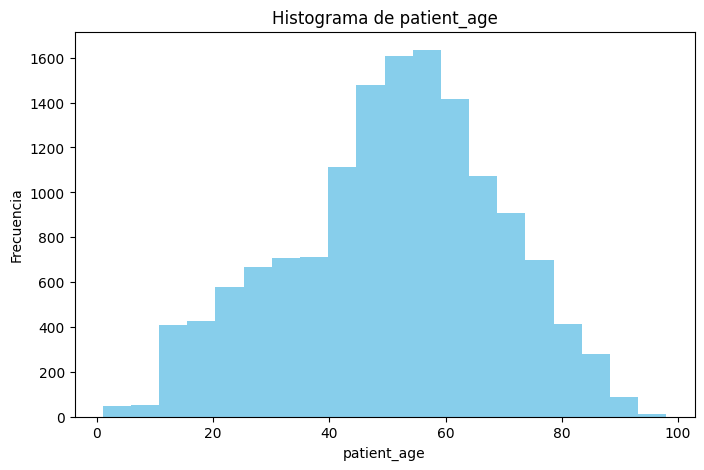

<Figure size 800x500 with 0 Axes>

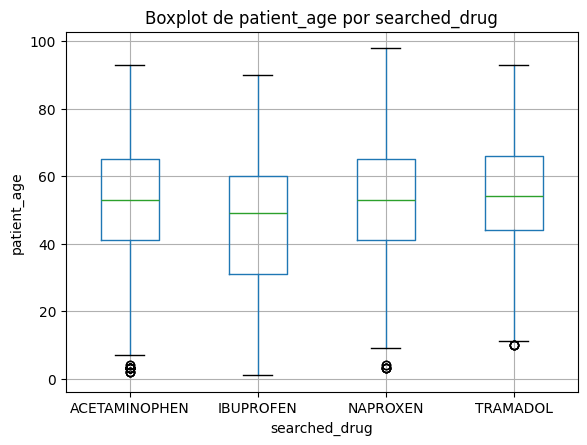

In [ ]:
import matplotlib.pyplot as plt

# Histograma para una variable numérica patient_age
col_hist = 'patient_age'
plt.figure(figsize=(8,5))
plt.hist(df[col_hist], bins=20, color='skyblue')
plt.title(f'Histograma de {col_hist}')
plt.xlabel(col_hist)
plt.ylabel('Frecuencia')
plt.show()

# Boxplot segmentado por la variable categórica searched_drug
segment_col = 'searched_drug'
if segment_col in df.columns:
    plt.figure(figsize=(8,5))
    df.boxplot(column=col_hist, by=segment_col)
    plt.title(f'Boxplot de {col_hist} por {segment_col}')
    plt.suptitle('')
    plt.xlabel(segment_col)
    plt.ylabel(col_hist)
    plt.show()


"" Conclusiones:

1- Observamos que la variable categórica searched_drug, la categoría Naproxen es la que presenta un valor mayor del parámetro moda, esto significa que es el analgésico más elegido y utilizado por los pacientes pero además son las edades en las que los mismos generan mayor cantidad de efectos adversos lo cual es un dato importante para el análisis del mercado de analgésicos.

2- El histograma muestra una distribución de las edades en relación a los registros, lo cual demuestra que las edades más frecuentes de los pacientes que consumen analgésicos y presentan eventos adversos son adultos entre 40 y 60 anos.

3- En relación al bloxpot podemos ver una amplia variabilidad de datos en las 4 categorías de drogas lo cual indica que las poblaciones en relación a sus edades son muy diversas a pesar de que se centren la mayoría de registros de eventos adversos en edades entre 40 y 60 . Ademas en las categoríás acetaminophen, naproxen y tramadol tenemos valores outliers que sería interesante analizar porque representan edades de pacientes pediátricos.